# Actividad 3
* Reto 1
  *   Determina los unbrales de los colores rojo y amarillo en  base a la imagen propuesta en este material (HSV.png)

<img src="IMG/HSV.png" alt="HSV.png" width="200">

  *   De las siguientes **(contorno2.png y Ejemplo2.png)** imagenes obtiene todos los contronos que corresponde al color de cada figura.

<img src="IMG/contorno2.png" alt="contorno2.png" width="200"><img src="IMG/Ejemplo2.png" alt="Ejemplo2.png.png" width="200">

 * Para la imagen Contorno 2.png.
   *  Los color de los contornos de las figuras seran de las sigueinte forma: 
   *  figuras de color azul el contorno sera de color rojo. 
   *  figuras de color rojo el contorno sera de color amarillo. 
   *  figuras de color amarillo el contorno sera de color azul. 
* Reto 2
 *   De las siguinetes imagenes **(Figuras.png y Suavizado.png)** determina las imagen que corresponde a un mismo color y coloca un contorno de color y tamaño del borde a tu eleccion. 
 
 <img src="IMG/Figuras.png" alt="Figuras.png" width="200"><img src="IMG/Suavizado.png" alt="Suavizado.png" width="200">



Librerías

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

RETO 1 — Umbrales HSV (Rojo y Amarillo)

Cargar imagen HSV

(np.float64(-0.5), np.float64(719.5), np.float64(354.5), np.float64(-0.5))

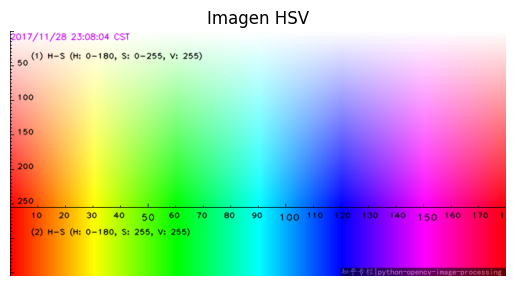

In [2]:
img_hsv = cv2.imread('IMG/HSV.png')
hsv = cv2.cvtColor(img_hsv, cv2.COLOR_BGR2HSV)

plt.imshow(cv2.cvtColor(img_hsv, cv2.COLOR_BGR2RGB))
plt.title("Imagen HSV")
plt.axis('off')

Rangos de color

In [3]:
# ROJO (tiene dos rangos en HSV)
rojo_bajo1 = np.array([0, 100, 100])
rojo_alto1 = np.array([10, 255, 255])

rojo_bajo2 = np.array([160, 100, 100])
rojo_alto2 = np.array([179, 255, 255])

# AMARILLO
amarillo_bajo = np.array([20, 100, 100])
amarillo_alto = np.array([35, 255, 255])

Máscaras de color

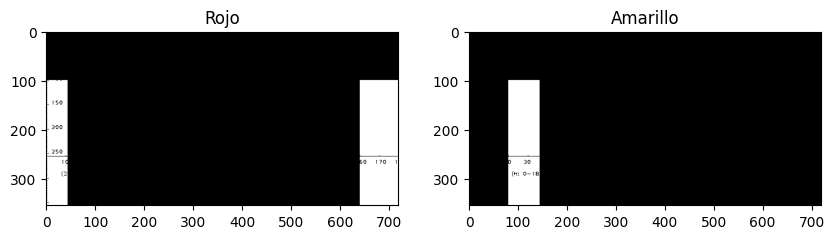

In [4]:
mask_rojo1 = cv2.inRange(hsv, rojo_bajo1, rojo_alto1)
mask_rojo2 = cv2.inRange(hsv, rojo_bajo2, rojo_alto2)
mask_rojo = mask_rojo1 + mask_rojo2

mask_amarillo = cv2.inRange(hsv, amarillo_bajo, amarillo_alto)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mask_rojo, cmap='gray')
plt.title("Rojo")

plt.subplot(1,2,2)
plt.imshow(mask_amarillo, cmap='gray')
plt.title("Amarillo")

plt.show()

RETO 1 — Contornos por color (contorno2.png)

Cargar imagen

(np.float64(-0.5), np.float64(658.5), np.float64(492.5), np.float64(-0.5))

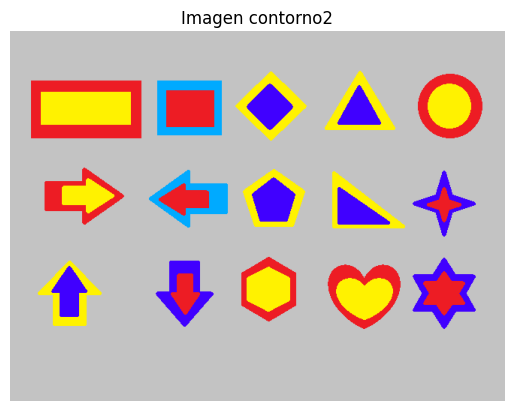

In [5]:
img = cv2.imread('IMG/contorno2.png')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagen contorno2")
plt.axis('off')

Definir azul también

In [6]:
# AZUL
azul_bajo = np.array([100, 100, 100])
azul_alto = np.array([130, 255, 255])

mask_azul = cv2.inRange(hsv, azul_bajo, azul_alto)

Crear máscaras completas

In [7]:
# Ya teníamos rojo y amarillo
mask_rojo1 = cv2.inRange(hsv, rojo_bajo1, rojo_alto1)
mask_rojo2 = cv2.inRange(hsv, rojo_bajo2, rojo_alto2)
mask_rojo = mask_rojo1 + mask_rojo2

mask_amarillo = cv2.inRange(hsv, amarillo_bajo, amarillo_alto)

Encontrar contornos

In [8]:
cont_rojo, _ = cv2.findContours(mask_rojo, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cont_amarillo, _ = cv2.findContours(mask_amarillo, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cont_azul, _ = cv2.findContours(mask_azul, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

Dibujar contornos con reglas pedidas

(np.float64(-0.5), np.float64(658.5), np.float64(492.5), np.float64(-0.5))

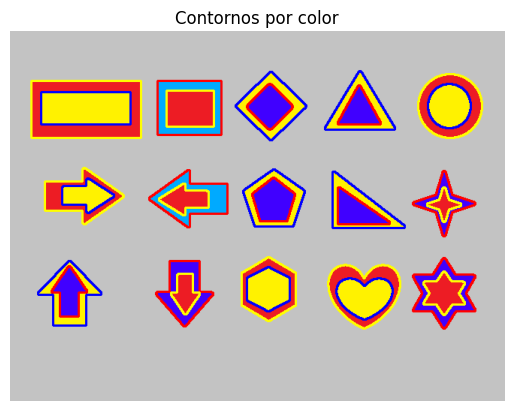

In [9]:
resultado = img.copy()

# Azul → contorno rojo
cv2.drawContours(resultado, cont_azul, -1, (0,0,255), 2)

# Rojo → contorno amarillo
cv2.drawContours(resultado, cont_rojo, -1, (0,255,255), 2)

# Amarillo → contorno azul
cv2.drawContours(resultado, cont_amarillo, -1, (255,0,0), 2)

plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title("Contornos por color")
plt.axis('off')

RETO 2 — Detectar mismo color (Figuras.png y Suavizado.png)

Cargar imágenes

In [10]:
img1 = cv2.imread('IMG/Figuras.png')
img2 = cv2.imread('IMG/Suavizado.png')

Detectar un color (ejemplo: rojo)

(np.float64(-0.5), np.float64(1599.5), np.float64(544.5), np.float64(-0.5))

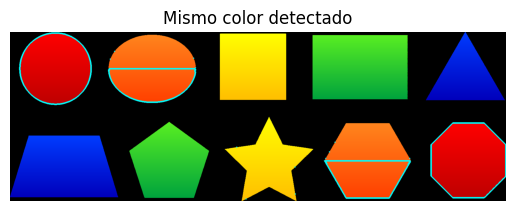

In [11]:
hsv1 = cv2.cvtColor(img1, cv2.COLOR_BGR2HSV)

mask_rojo1 = cv2.inRange(hsv1, rojo_bajo1, rojo_alto1)
mask_rojo2 = cv2.inRange(hsv1, rojo_bajo2, rojo_alto2)
mask_rojo_total = mask_rojo1 + mask_rojo2

contornos, _ = cv2.findContours(mask_rojo_total, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

resultado = img1.copy()
cv2.drawContours(resultado, contornos, -1, (255,255,0), 3)

plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title("Mismo color detectado")
plt.axis('off')

Repetir para segunda imagen

(np.float64(-0.5), np.float64(866.5), np.float64(492.5), np.float64(-0.5))

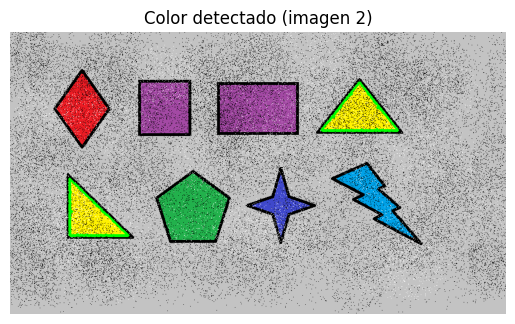

In [12]:
hsv2 = cv2.cvtColor(img2, cv2.COLOR_BGR2HSV)

mask = cv2.inRange(hsv2, amarillo_bajo, amarillo_alto)

contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

resultado2 = img2.copy()
cv2.drawContours(resultado2, contornos, -1, (0,255,0), 3)

plt.imshow(cv2.cvtColor(resultado2, cv2.COLOR_BGR2RGB))
plt.title("Color detectado (imagen 2)")
plt.axis('off')